# Deep Learning, DL Models and Applications
## Skill Development Tasks (1-15)

### Implementations:
- Neural Networks from Scratch
- Optimization Algorithms
- CNN Architectures
- Sequence Models
- Generative Models
- Transformers
- Distributed Training

### Frameworks:
- NumPy
- PyTorch
- TorchVision
- Matplotlib
- SciPy
- Scikit-Learn

Nandana R Nair

In [1]:
# Install Required Libraries
!pip install einops albumentations torchinfo

In [2]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ============================================================
# TASK 10
# Wasserstein GAN with Gradient Penalty (WGAN-GP)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision.utils import make_grid

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
#Hyperparameters
IMAGE_SIZE = 28
CHANNELS = 1
LATENT_DIM = 100

BATCH_SIZE = 64

EPOCHS = 100

LR = 1e-4

CRITIC_ITERATIONS = 5

LAMBDA_GP = 10

In [5]:
#Dataset
transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))

])

dataset = datasets.MNIST(

    root="./data",

    train=True,

    transform=transform,

    download=True

)

loader = DataLoader(

    dataset,

    batch_size=BATCH_SIZE,

    shuffle=True

)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.96MB/s]


In [6]:
#Generator
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(LATENT_DIM,256),

            nn.ReLU(True),

            nn.Linear(256,512),

            nn.ReLU(True),

            nn.Linear(512,1024),

            nn.ReLU(True),

            nn.Linear(1024,784),

            nn.Tanh()

        )

    def forward(self,z):

        img=self.model(z)

        return img.view(-1,1,28,28)

In [7]:
#Critic
class Critic(nn.Module):

    def __init__(self):

        super().__init__()

        self.model=nn.Sequential(

            nn.Linear(784,512),

            nn.LeakyReLU(0.2),

            nn.Linear(512,256),

            nn.LeakyReLU(0.2),

            nn.Linear(256,1)

        )

    def forward(self,x):

        x=x.view(x.size(0),-1)

        return self.model(x)

In [8]:
#Models
generator = Generator().to(device)

critic = Critic().to(device)

In [9]:
#Optimizers
g_optimizer = optim.Adam(

    generator.parameters(),

    lr=LR,

    betas=(0.0,0.9)

)

c_optimizer = optim.Adam(

    critic.parameters(),

    lr=LR,

    betas=(0.0,0.9)

)

In [10]:
#Gradient Penalty
def gradient_penalty(

        critic,

        real,

        fake):

    batch_size = real.size(0)

    alpha = torch.rand(

        batch_size,

        1,

        1,

        1,

        device=device

    )

    interpolated = alpha*real + (1-alpha)*fake

    interpolated.requires_grad_(True)

    mixed_scores = critic(interpolated)

    gradients = torch.autograd.grad(

        outputs=mixed_scores,

        inputs=interpolated,

        grad_outputs=torch.ones_like(mixed_scores),

        create_graph=True,

        retain_graph=True

    )[0]

    gradients = gradients.view(batch_size,-1)

    gradient_norm = gradients.norm(2,dim=1)

    gp = ((gradient_norm-1)**2).mean()

    return gp

Epoch 1/100 | Critic -6.6922 | Generator 3.9201
Epoch 2/100 | Critic -5.7819 | Generator 6.7464
Epoch 3/100 | Critic -4.6007 | Generator 4.5460
Epoch 4/100 | Critic -4.6470 | Generator 0.7083
Epoch 5/100 | Critic -3.5571 | Generator 2.5921
Epoch 6/100 | Critic -3.3540 | Generator -0.1545
Epoch 7/100 | Critic -3.7971 | Generator 1.9069
Epoch 8/100 | Critic -3.1263 | Generator 1.7398
Epoch 9/100 | Critic -2.2992 | Generator 1.9430
Epoch 10/100 | Critic -3.5023 | Generator 2.1709


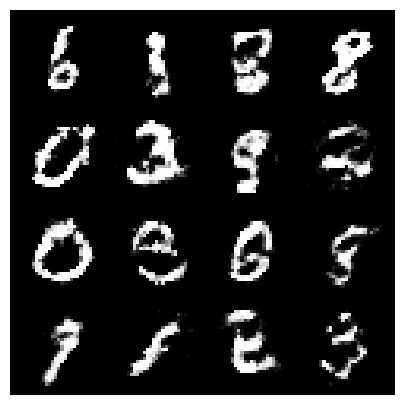

Epoch 11/100 | Critic -3.0893 | Generator 1.3430
Epoch 12/100 | Critic -2.3416 | Generator -0.8619
Epoch 13/100 | Critic -2.5973 | Generator 0.4881
Epoch 14/100 | Critic -2.7810 | Generator 2.6152
Epoch 15/100 | Critic -2.0444 | Generator -1.6293
Epoch 16/100 | Critic -1.4861 | Generator 1.9485
Epoch 17/100 | Critic -3.0379 | Generator -2.4126
Epoch 18/100 | Critic -2.4485 | Generator -3.4393
Epoch 19/100 | Critic -3.0173 | Generator -2.7073
Epoch 20/100 | Critic -1.4242 | Generator -2.3836


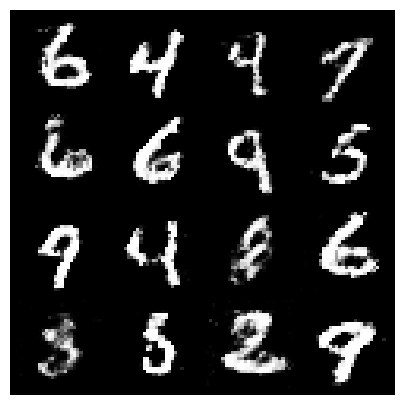

Epoch 21/100 | Critic -2.4970 | Generator 2.2803
Epoch 22/100 | Critic -1.5464 | Generator -1.0325
Epoch 23/100 | Critic -1.6862 | Generator -1.2779
Epoch 24/100 | Critic -1.3192 | Generator 1.3039
Epoch 25/100 | Critic -2.0486 | Generator 0.3090
Epoch 26/100 | Critic -2.0624 | Generator 0.2039
Epoch 27/100 | Critic -1.6300 | Generator 1.5463
Epoch 28/100 | Critic -2.2605 | Generator 0.5298
Epoch 29/100 | Critic -2.4718 | Generator 0.7685
Epoch 30/100 | Critic -3.3813 | Generator 3.5588


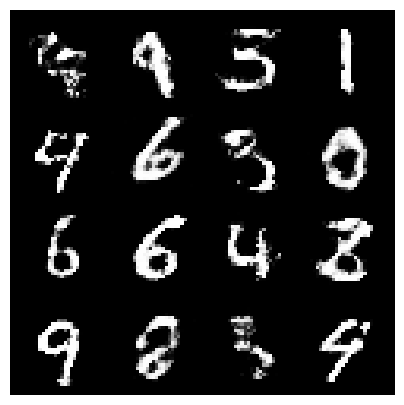

Epoch 31/100 | Critic -1.9872 | Generator 0.0095
Epoch 32/100 | Critic -1.0704 | Generator 1.3614
Epoch 33/100 | Critic -1.9988 | Generator -0.1589
Epoch 34/100 | Critic -1.9912 | Generator -1.2895
Epoch 35/100 | Critic -1.8361 | Generator -1.5324
Epoch 36/100 | Critic -2.2322 | Generator -3.7450
Epoch 37/100 | Critic -2.6900 | Generator 2.1806
Epoch 38/100 | Critic -1.8058 | Generator -0.2194
Epoch 39/100 | Critic -3.0035 | Generator -1.4757
Epoch 40/100 | Critic -2.0362 | Generator -4.7050


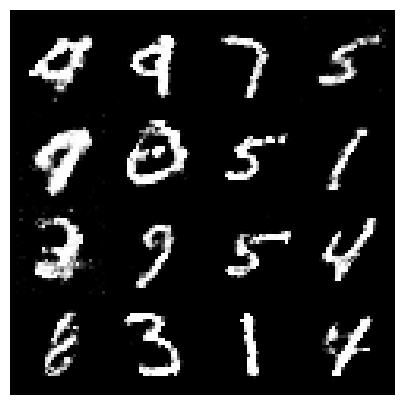

Epoch 41/100 | Critic -2.2484 | Generator -0.1809
Epoch 42/100 | Critic -1.0131 | Generator -0.4120
Epoch 43/100 | Critic -2.3568 | Generator -4.8818
Epoch 44/100 | Critic -1.3383 | Generator 1.2322
Epoch 45/100 | Critic -1.9718 | Generator -0.9163
Epoch 46/100 | Critic -1.4483 | Generator -4.1737
Epoch 47/100 | Critic -0.9305 | Generator -2.9647
Epoch 48/100 | Critic -1.7865 | Generator -0.7373
Epoch 49/100 | Critic -0.9105 | Generator -1.2603
Epoch 50/100 | Critic -0.8002 | Generator 0.7411


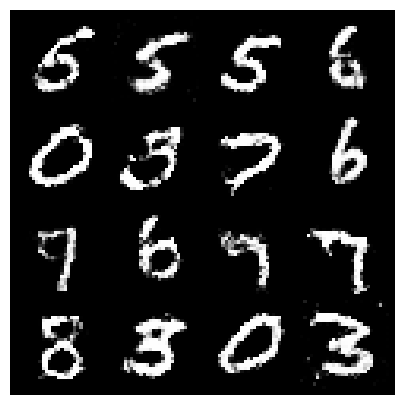

Epoch 51/100 | Critic -2.2575 | Generator 3.0001
Epoch 52/100 | Critic -1.8015 | Generator -3.1940
Epoch 53/100 | Critic -1.1430 | Generator -0.2338
Epoch 54/100 | Critic -2.4601 | Generator -2.3407
Epoch 55/100 | Critic -1.9527 | Generator -0.9124
Epoch 56/100 | Critic -2.1168 | Generator -5.0281
Epoch 57/100 | Critic -1.8325 | Generator 0.4458
Epoch 58/100 | Critic -2.0227 | Generator 1.2799
Epoch 59/100 | Critic -1.3615 | Generator 1.3181
Epoch 60/100 | Critic -2.0983 | Generator 4.4929


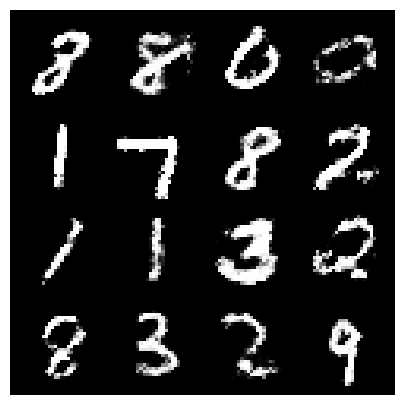

Epoch 61/100 | Critic -1.2599 | Generator 2.6659
Epoch 62/100 | Critic -1.4154 | Generator -3.8212
Epoch 63/100 | Critic -1.8604 | Generator -2.6304
Epoch 64/100 | Critic -1.2705 | Generator -3.5021
Epoch 65/100 | Critic -1.5034 | Generator -6.1674
Epoch 66/100 | Critic -1.4259 | Generator -2.9373
Epoch 67/100 | Critic -0.8781 | Generator -8.5120
Epoch 68/100 | Critic -1.5390 | Generator 4.5074
Epoch 69/100 | Critic -1.5192 | Generator -5.6869
Epoch 70/100 | Critic -1.8142 | Generator -3.2203


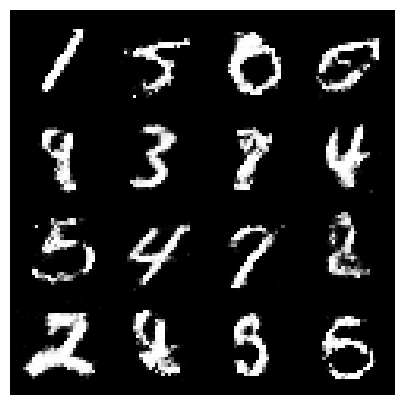

Epoch 71/100 | Critic -1.5556 | Generator -5.4924
Epoch 72/100 | Critic -1.7530 | Generator 2.7152
Epoch 73/100 | Critic -2.7223 | Generator -8.5147
Epoch 74/100 | Critic -1.6592 | Generator -0.0073
Epoch 75/100 | Critic -1.2017 | Generator -0.6750
Epoch 76/100 | Critic -1.1634 | Generator -4.7137
Epoch 77/100 | Critic -1.6857 | Generator -3.7984
Epoch 78/100 | Critic -1.3119 | Generator 0.3852
Epoch 79/100 | Critic -1.6577 | Generator -9.8091
Epoch 80/100 | Critic -0.8942 | Generator -4.4591


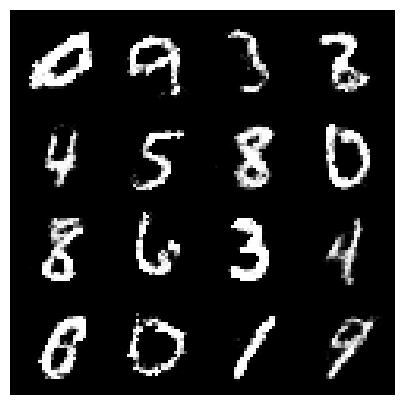

Epoch 81/100 | Critic -1.5558 | Generator 2.4748
Epoch 82/100 | Critic -1.4805 | Generator -0.4584
Epoch 83/100 | Critic -1.7649 | Generator -1.9394
Epoch 84/100 | Critic -0.2437 | Generator -2.3504
Epoch 85/100 | Critic -1.9827 | Generator -6.1791
Epoch 86/100 | Critic -1.2379 | Generator 0.5403
Epoch 87/100 | Critic -0.4934 | Generator -2.0179
Epoch 88/100 | Critic -1.3904 | Generator 0.0401
Epoch 89/100 | Critic -1.1406 | Generator -6.1521
Epoch 90/100 | Critic -1.7976 | Generator -3.4646


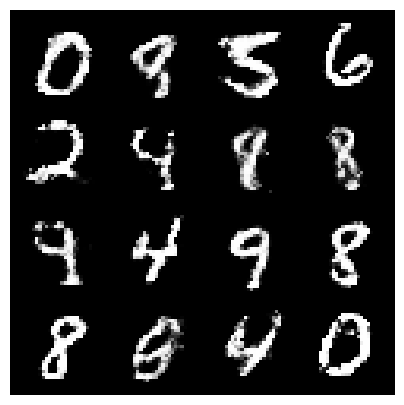

Epoch 91/100 | Critic -1.6299 | Generator -4.5902
Epoch 92/100 | Critic -1.1187 | Generator -3.7871
Epoch 93/100 | Critic -1.1155 | Generator -1.5279
Epoch 94/100 | Critic -2.0578 | Generator -2.0449
Epoch 95/100 | Critic -2.0362 | Generator -5.8443
Epoch 96/100 | Critic -1.3754 | Generator 0.8525
Epoch 97/100 | Critic -1.2543 | Generator -0.5997
Epoch 98/100 | Critic -0.4006 | Generator -3.5030
Epoch 99/100 | Critic -0.7649 | Generator -5.0858
Epoch 100/100 | Critic -0.4835 | Generator -9.7644


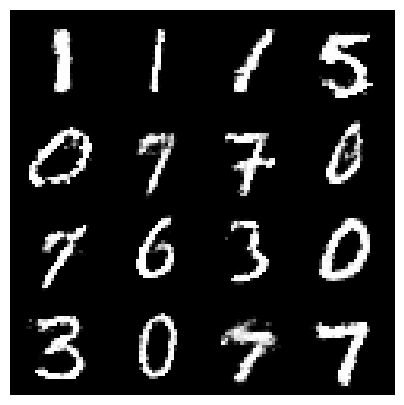

In [11]:
#Training Loop
generator_losses=[]

critic_losses=[]

for epoch in range(EPOCHS):

    for real,_ in loader:

        real=real.to(device)

        batch_size=real.size(0)

        ####################################################
        # Train Critic
        ####################################################

        for _ in range(CRITIC_ITERATIONS):

            noise=torch.randn(
                batch_size,
                LATENT_DIM,
                device=device
            )

            fake=generator(noise)

            critic_real=critic(real).mean()

            critic_fake=critic(fake.detach()).mean()

            gp=gradient_penalty(
                critic,
                real,
                fake.detach()
            )

            critic_loss=(
                -(critic_real)
                +critic_fake
                +LAMBDA_GP*gp
            )

            c_optimizer.zero_grad()

            critic_loss.backward()

            c_optimizer.step()

        ####################################################
        # Train Generator
        ####################################################

        noise=torch.randn(

            batch_size,

            LATENT_DIM,

            device=device

        )

        fake=generator(noise)

        gen_loss=-critic(fake).mean()

        g_optimizer.zero_grad()

        gen_loss.backward()

        g_optimizer.step()

    generator_losses.append(gen_loss.item())

    critic_losses.append(critic_loss.item())

    print(

        f"Epoch {epoch+1}/{EPOCHS}"

        f" | Critic {critic_loss:.4f}"

        f" | Generator {gen_loss:.4f}"

    )

    ####################################################
    # Show Images
    ####################################################

    if (epoch+1)%10==0:

        with torch.no_grad():

            sample=generator(

                torch.randn(

                    16,

                    LATENT_DIM,

                    device=device

                )

            )

        grid=make_grid(

            sample,

            nrow=4,

            normalize=True

        )

        plt.figure(figsize=(5,5))

        plt.imshow(

            grid.cpu().permute(1,2,0)

        )

        plt.axis("off")

        plt.show()

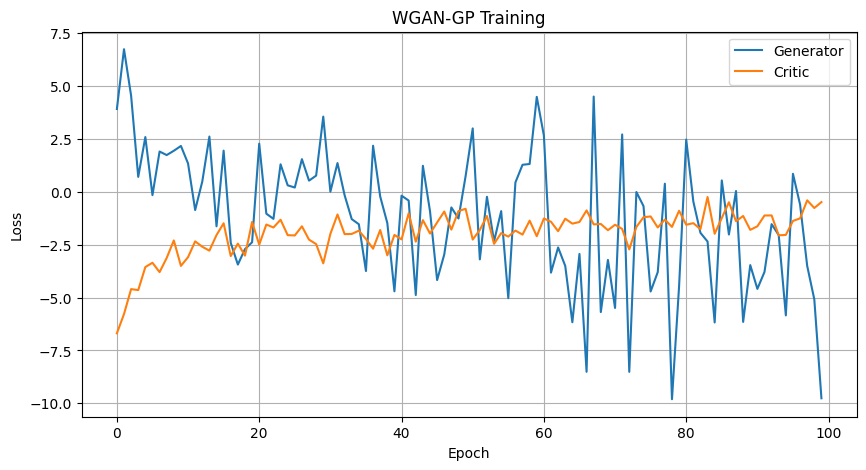

In [12]:
#Loss Curves
plt.figure(figsize=(10,5))

plt.plot(

    generator_losses,

    label="Generator"

)

plt.plot(

    critic_losses,

    label="Critic"

)

plt.legend()

plt.grid(True)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("WGAN-GP Training")

plt.show()

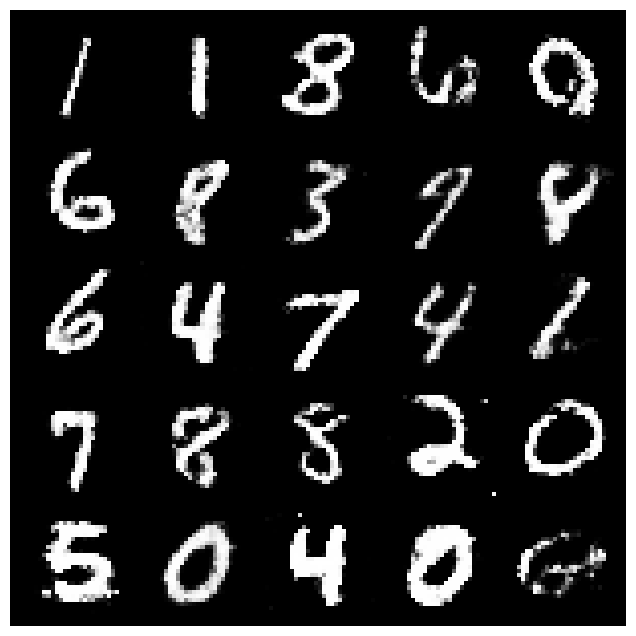

In [13]:
#Final Image Generation
with torch.no_grad():

    noise=torch.randn(

        25,

        LATENT_DIM,

        device=device

    )

    images=generator(noise)

grid=make_grid(

    images,

    nrow=5,

    normalize=True

)

plt.figure(figsize=(8,8))

plt.imshow(

    grid.cpu().permute(1,2,0)

)

plt.axis("off")

plt.show()